# AI-Driven Multi-Agent Sports Front Office — Walkthrough

This notebook is a **teaching walkthrough** of a small agentic system: four
specialized "agents" collaborate to evaluate an NBA trade.

| Agent | Job |
|---|---|
| 🕵️ **Data Scout** | Gets roster, salary, and stat data |
| 📊 **Quantitative Analyst** | Scores player value with an aging-curve model |
| ⚖️ **CBA / Cap Specialist** | Checks the trade is legal under salary-cap rules |
| 🧑‍💼 **General Manager** | Synthesizes everything into a graded recommendation |

Everything below runs **offline with no API key** — the logic is plain,
auditable Python. At the end we show how an optional LLM layer (CrewAI)
can sit on top of this same verified data to add narrative reasoning.

**How to use this notebook when teaching:** run one cell at a time, pause on
each markdown block, and let the audience predict the output before running
the next cell.

## Setup
Make the project root importable, then pull in each agent's building blocks.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src.tools.nba_data_tool import fetch_league_dataset, find_player, load_cap_rules, team_payroll
from src.tools.quant_analysis import age_multiplier, player_value_score, trade_impact_summary
from src.tools.cap_rules import check_trade_legality, suggest_balancing_move, team_cap_status
from src.pipeline import run_trade_analysis, render_markdown_report


## Agent 1 — Data Scout 🕵️

The Scout's only job is to fetch trustworthy data. It tries the live
`nba_api` first; if that's unreachable (no internet, rate-limited, sandboxed
environment) it silently falls back to a bundled offline dataset so the rest
of the pipeline never breaks. That fallback is the whole `use_live=False`
path you'll see below.

In [2]:
teams = fetch_league_dataset(use_live=False)  # offline dataset for a reliable demo
cap_rules = load_cap_rules()

print("Teams available:", list(teams.keys()))
print()
print("Boston Celtics roster:")
for p in teams["BOS"]["roster"]:
    print(f"  {p['name']:<20} {p['position']:<3} age {p['age']:<3} ${p['salary']:,}")


Teams available: ['BOS', 'LAL', 'DAL', 'MIA']

Boston Celtics roster:
  Jaylen Brown         SG  age 29  $49,205,800
  Derrick White        PG  age 31  $28,966,700
  Jrue Holiday         PG  age 35  $32,400,000
  Kristaps Porzingis   C   age 30  $30,678,000
  Sam Hauser           SF  age 27  $10,000,000


In [3]:
bos_payroll = team_payroll(teams, "BOS")
lal_payroll = team_payroll(teams, "LAL")
print(f"BOS total payroll: ${bos_payroll:,}")
print(f"LAL total payroll: ${lal_payroll:,}")
print(f"2025-26 salary cap: ${cap_rules['salary_cap']:,}")


BOS total payroll: $151,250,500
LAL total payroll: $113,919,000
2025-26 salary cap: $154,647,000


## Agent 2 — Quantitative Analyst 📊

Instead of a black-box ML model (harder to explain live), this agent uses a
transparent **aging curve**: a multiplier applied to a player's current
production, peaking around age 27 and declining on either side. That curve
is what lets the agent "project" value into the future, not just describe
the present.

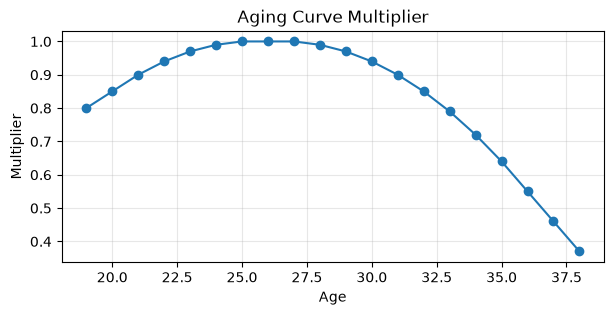

In [4]:
ages = list(range(19, 39))
multipliers = [age_multiplier(a) for a in ages]

plt.figure(figsize=(7, 3))
plt.plot(ages, multipliers, marker="o")
plt.title("Aging Curve Multiplier")
plt.xlabel("Age")
plt.ylabel("Multiplier")
plt.grid(alpha=0.3)
plt.show()


Jaylen Brown         value score = 70.5
Kristaps Porzingis   value score = 62.6
D'Angelo Russell     value score = 48.3
Gabe Vincent         value score = 25.9


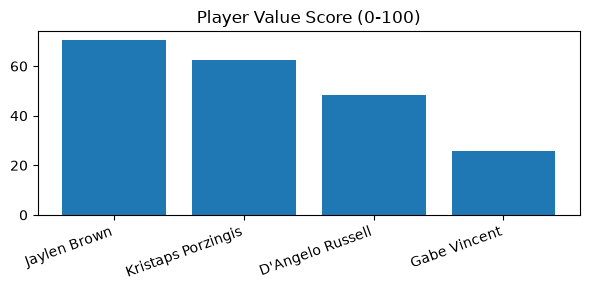

In [5]:
sample_names = ["Jaylen Brown", "Kristaps Porzingis", "D'Angelo Russell", "Gabe Vincent"]
scores = []
for name in sample_names:
    _, player = find_player(teams, name)
    scores.append(player_value_score(player))
    print(f"{name:<20} value score = {scores[-1]}")

plt.figure(figsize=(6, 3))
plt.bar(sample_names, scores)
plt.title("Player Value Score (0-100)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Agent 3 — CBA / Cap Specialist ⚖️

This agent audits a trade against a simplified version of the real NBA CBA:
- **Under the cap** → can take back incoming salary up to cap room + outgoing.
- **Over the cap / taxpayer** → salary must "match" within banded multipliers.
- **First apron** → can take back at most 100% of outgoing + \$250k, no aggregating players.
- **Second apron** → cannot take back *more* salary than sent, no aggregating.

Let's check one legal trade and one illegal trade directly, without running
the whole pipeline, so you can see exactly what this agent decides.

In [6]:
# A team that's deep into the luxury tax trying to take back too much salary
result = check_trade_legality(
    team_abbr="DEMO",
    current_payroll=210_000_000,   # over the second apron
    outgoing_salary=10_000_000,
    incoming_salary=15_000_000,
    outgoing_player_count=1,
    cap_rules=cap_rules,
)
print("Cap status:", result.cap_status.value)
print("Legal?", result.legal)
for v in result.violations:
    print(" -", v)

suggestion = suggest_balancing_move(result)
print("\nSuggested fix:", suggestion)


Cap status: Over the Second Apron
Legal? False
 - Second-apron team cannot take back MORE salary than it sends out. Incoming $15,000,000 > outgoing $10,000,000.

Suggested fix: DEMO needs to shed roughly $5,000,000 more in outgoing salary (e.g. attach a smaller salaried player or ask the other side to include less salary) to bring this trade within CBA limits.


Notice the agent doesn't just say "no" — it proposes a concrete dollar
figure to fix the trade. That's the **feedback-loop** pattern the original
project blueprint calls for: when the Cap Specialist rejects a trade, it
hands back something actionable instead of a dead end.

## Agent 4 — General Manager 🧑‍💼

The GM agent doesn't recompute anything — it **synthesizes** what the other
three agents already found into one graded recommendation. This is the
`run_trade_analysis()` function, which chains all four agents together
exactly like the diagram in the README.

In [7]:
trade = {
    "team_a": "BOS",
    "team_b": "LAL",
    "team_a_sends": ["Jrue Holiday"],
    "team_b_sends": ["D'Angelo Russell", "Gabe Vincent"],
}

result = run_trade_analysis(trade, use_live_data=False)
report = render_markdown_report(result)
display(Markdown(report))


# Trade Analysis Report (2025-26)

**Proposed trade:** BOS sends Jrue Holiday to LAL for D'Angelo Russell, Gabe Vincent.

## Boston Celtics (BOS) — Grade: A
- Cap status: **Under the Salary Cap** (payroll $151,250,500)
- Trade legality: ✅ LEGAL (outgoing $32,400,000, incoming $29,492,000, max allowed incoming $35,796,500)
- Quant impact: value acquired 74.2, value surrendered 32.5, **net +41.7**
- Roster before trade: avg age 30.4, positions {'SG': 1, 'PG': 2, 'C': 1, 'SF': 1}

## Los Angeles Lakers (LAL) — Grade: D
- Cap status: **Under the Salary Cap** (payroll $113,919,000)
- Trade legality: ✅ LEGAL (outgoing $29,492,000, incoming $32,400,000, max allowed incoming $70,220,000)
- Quant impact: value acquired 32.5, value surrendered 74.2, **net -41.7**
- Roster before trade: avg age 28.8, positions {'PF': 2, 'PG': 2, 'SG': 1}


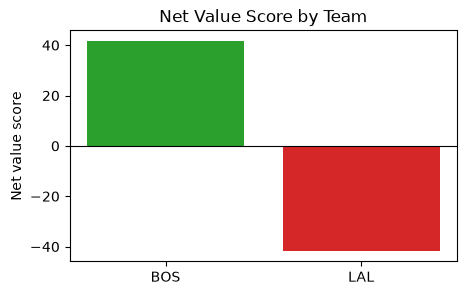

In [8]:
teams_in_trade = list(result["teams"].keys())
net_scores = [result["teams"][t]["impact"]["net_value_score"] for t in teams_in_trade]

plt.figure(figsize=(5, 3))
colors = ["#2ca02c" if s >= 0 else "#d62728" for s in net_scores]
plt.bar(teams_in_trade, net_scores, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Net Value Score by Team")
plt.ylabel("Net value score")
plt.show()


## Try It Yourself: An Illegal Trade

Let's run the *full* pipeline on a trade that should get flagged, so you can
see the Cap Specialist's veto propagate all the way to the GM's final grade.
We'll temporarily pretend BOS is deep into the second apron by editing the
in-memory dataset (no files touched).

In [9]:
import copy

hard_capped_teams = copy.deepcopy(teams)
# Inflate BOS's roster salaries so total payroll clears the second apron.
for p in hard_capped_teams["BOS"]["roster"]:
    p["salary"] = int(p["salary"] * 1.6)

from src.tools.quant_analysis import analyze_team_needs
from src.pipeline import _resolve_players  # internal helper, fine for a demo

a_payroll = team_payroll(hard_capped_teams, "BOS")
print(f"BOS payroll after inflation: ${a_payroll:,} (2nd apron starts at ${cap_rules['second_apron']:,})")
print("Cap status:", team_cap_status(a_payroll, cap_rules).value)

a_sends = _resolve_players(hard_capped_teams, ["Jaylen Brown", "Sam Hauser"])  # 2 players = aggregation
b_sends = _resolve_players(hard_capped_teams, ["D'Angelo Russell"])

legality = check_trade_legality(
    team_abbr="BOS",
    current_payroll=a_payroll,
    outgoing_salary=sum(p["salary"] for p in a_sends),
    incoming_salary=sum(p["salary"] for p in b_sends),
    outgoing_player_count=len(a_sends),
    cap_rules=cap_rules,
)
print("\nLegal?", legality.legal)
for v in legality.violations:
    print(" -", v)


BOS payroll after inflation: $242,000,800 (2nd apron starts at $207,824,000)
Cap status: Over the Second Apron

Legal? False
 - Second-apron teams cannot aggregate multiple outgoing players' salaries in a single trade.


Two violations should show up: taking back too much salary for a
second-apron team, *and* illegally aggregating two outgoing players into one
trade. This is exactly the kind of rule a human GM could get wrong under
deadline pressure — which is the pitch for building this as an agent in the
first place.

## Where the LLM Actually Comes In

Everything above is deterministic Python — good for the parts where being
*right* matters more than being *creative* (salary math, legality). The
project also ships an optional **CrewAI** layer (`src/crew.py`) with four
LLM-driven agent personas that reason over these same verified numbers to
write a natural-language recommendation, weigh team needs, and suggest
trade packages. Run it from the command line with:

```bash
python -m src.main examples/sample_trade.json --agentic
```

(requires `pip install crewai` and an `ANTHROPIC_API_KEY`).

### Discussion questions for your audience
1. Why compute the salary-cap math in plain Python instead of asking an LLM to do it?
2. What would break if the Data Scout's offline fallback didn't exist?
3. How would you extend the Cap Specialist's feedback loop into an actual
   negotiation between two GM agents?